In [1]:
%load_ext autoreload
%autoreload 2

%reload_ext autoreload

In [2]:
from satellite_RFI.src.satellite_sims import satellite_sim as ss
import time
import pickle
import astropy.units as u
from datetime import datetime
import tqdm
import os


import scipy as sp
import numpy as np
import pandas as pd
import scipy.optimize as opt
import matplotlib.pyplot as plt

In [3]:
obs_time_input=None#'2021 9 30 20 06 36'
# fname = '1554156377'
fname = '1551055211'


"""
Establishing the file name
"""
if obs_time_input!=None:
    obs_time_in=[int(x) for x in obs_time_input.split()]
    obs_time = datetime(obs_time_in[0], obs_time_in[1], obs_time_in[2], obs_time_in[3], obs_time_in[4], obs_time_in[5])
    dt = obs_time.strftime('%Y-%m-%d %H:%M:%S')
    fname = int((obs_time - datetime(1970, 1, 1)).total_seconds())
    print ("File name to be used is: "+str(fname))

else:
    print ("File name to be used is: "+str(fname))
    dt = (datetime.utcfromtimestamp(float(fname)).strftime('%Y-%m-%d %H:%M:%S'))
    print ("Date of observation date: "+str(dt))



File name to be used is: 1551055211
Date of observation date: 2019-02-25 00:40:11


In [4]:
katdal_info = pickle.load(open('../../../Observation_results/Untangle/'+str(fname)+'/'+str(fname)+'_katdal_info.p', 'rb'), encoding='latin1')



info = [katdal_info[i] for i in katdal_info.keys()]

nd_s0=katdal_info['nd_s0']
nd_s0_coords=katdal_info['nd_s0_coords']
frequency=katdal_info['frequency']
fs=1000
fe=1500

data_save='../../../Observation_results/Untangle/'+str(fname)+'/sat_sims/'
if os.path.exists(data_save)==False:
    os.mkdir(data_save)
    
data_mkat = '../../../Observation_results/Untangle/'+str(fname)+'/'

In [5]:

sim = ss(file_name=fname, sats_only=None, data_loc=data_mkat, sat_loc='../../../Observation_results/Untangle/'+str(fname)+'/',
            survey_info=[nd_s0, nd_s0_coords, frequency], sat_info='../Satellite_simulations/Satellite_Catalogue/table3B_satellite_v3.csv',
            plots_loc='../../../Observation_results/Untangle/Plots/'+str(fname)+'/',
            sat_beam='emss_beam_r', frequency_range=[fs,fe], constellations=['GPS', 'BDS'])



Number of constellations:  2
Length of the satellite catalogue:  33


In [6]:
dic = {'Alpha':np.ones(sim.alpha_len)*1}   # Parameter of ones based on the length of the satellite signals

In [7]:
sim.excecute(dic['Alpha'], obs_time_start=nd_s0[1], obs_time_end=nd_s0[-2], obs_frequency_start=1100, obs_frequency_end=1350, 
            file_bias_choice=[1,1], add_sub=[1, 1], band_lvl=[None, None])



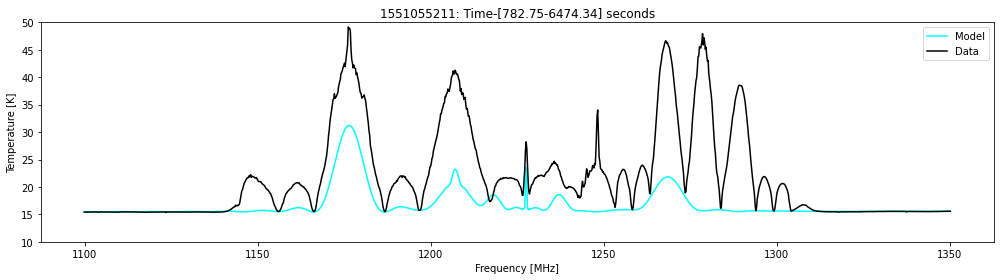

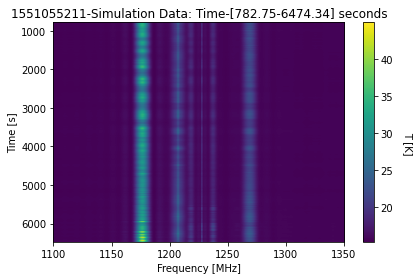

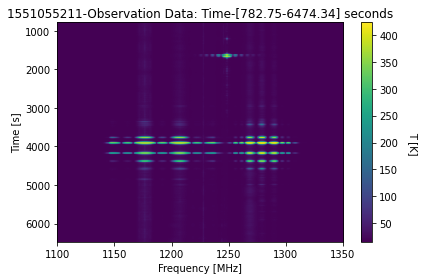

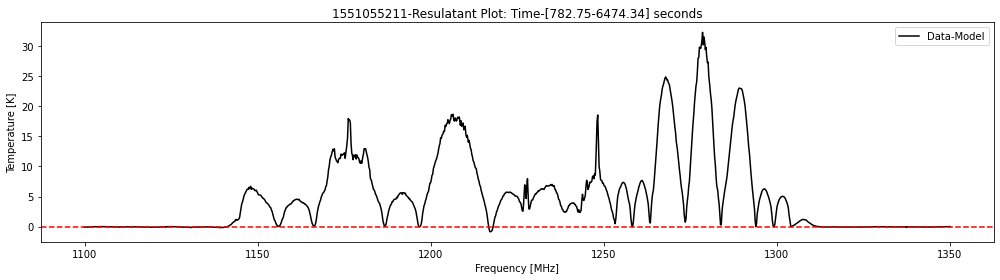

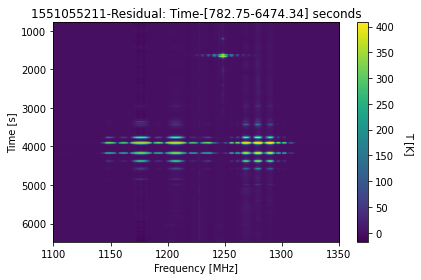

In [8]:
sim.plotting(individual=None, logger=1, axis_limit=[None, None, 10, 50], tod_limit=None, save_file=None, file_type='pdf')
